In [48]:
#installing Kaggle library
!pip install kaggle

In [49]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [50]:
 #Kaggle api
!kaggle competitions download -c dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [51]:
# Extracting compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [52]:
# Extracting compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [91]:
import os
# counting the number of files in Train folder
path, dirs, files = next(os.walk('/content/train'))

files_count = len(files)
print('Number of files in Train folder', files_count)

Number of files in Train folder 25000


In [54]:
file_names = os.listdir('/content/train')
print(file_names)

['dog.4708.jpg', 'dog.11061.jpg', 'dog.10984.jpg', 'dog.2742.jpg', 'dog.9525.jpg', 'cat.10772.jpg', 'dog.4460.jpg', 'cat.5592.jpg', 'cat.8858.jpg', 'dog.5734.jpg', 'cat.7714.jpg', 'cat.3887.jpg', 'dog.5666.jpg', 'dog.4419.jpg', 'dog.4255.jpg', 'cat.8546.jpg', 'dog.4995.jpg', 'dog.3264.jpg', 'dog.9038.jpg', 'dog.12496.jpg', 'dog.9725.jpg', 'dog.2511.jpg', 'cat.6759.jpg', 'cat.9752.jpg', 'dog.6184.jpg', 'dog.9386.jpg', 'cat.11638.jpg', 'dog.8148.jpg', 'cat.1512.jpg', 'cat.9949.jpg', 'cat.4080.jpg', 'cat.4081.jpg', 'cat.1608.jpg', 'dog.9135.jpg', 'dog.10086.jpg', 'dog.3130.jpg', 'dog.11696.jpg', 'cat.4546.jpg', 'dog.9917.jpg', 'cat.4502.jpg', 'dog.3486.jpg', 'dog.5541.jpg', 'cat.735.jpg', 'dog.4799.jpg', 'dog.9308.jpg', 'cat.933.jpg', 'cat.11078.jpg', 'dog.11264.jpg', 'dog.10241.jpg', 'cat.567.jpg', 'cat.5737.jpg', 'cat.7382.jpg', 'dog.8189.jpg', 'dog.3221.jpg', 'cat.2771.jpg', 'cat.10839.jpg', 'cat.1817.jpg', 'dog.8657.jpg', 'cat.7219.jpg', 'dog.280.jpg', 'dog.4638.jpg', 'cat.5174.jpg', 

##Importing libraries

In [92]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

## Display images dog and cat

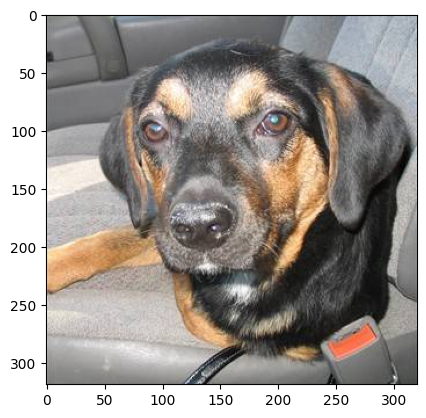

In [56]:
img = mpimg.imread('/content/train/dog.4460.jpg')
plt.imshow(img)
plt.show()

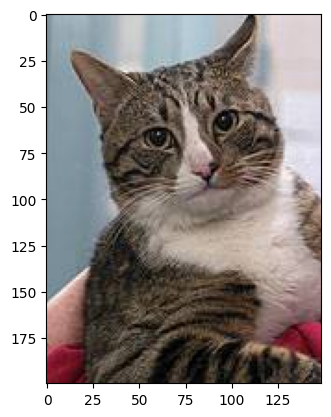

In [57]:
img = mpimg.imread('/content/train/cat.10772.jpg')
plt.imshow(img)
plt.show()

In [58]:
file_names = os.listdir('/content/train')

for i in range(5):

  name = file_names[i]
  print(name[0:3])

dog
dog
dog
dog
dog


In [59]:
file_names = os.listdir('/content/train')

dog_counter = 0
cat_counter = 0

for img_file in file_names:
  name = img_file[0:3]

  if(name == 'dog'):
    dog_counter += 1
  else:
    cat_counter += 1


print('Number fo dogs', dog_counter)
print('Number of cats', cat_counter)


Number fo dogs 12500
Number of cats 12500


Resize all images

In [61]:
#creating directory
os.mkdir('/content/images_resized')

FileExistsError: [Errno 17] File exists: '/content/images_resized'

In [62]:
original_folder = '/content/train/'
resized_folder = '/content/images_resized/'

for i in range(2000):

  filenames = os.listdir(original_folder)[i]
  img_path = original_folder + filenames

   # open file and resize
  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  newImgPath = resized_folder + filenames
  img.save(newImgPath)

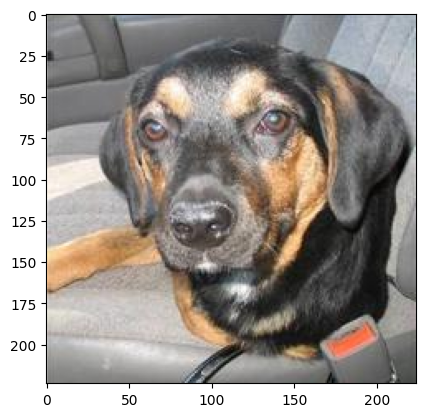

In [63]:
#resized dog image
img = mpimg.imread('/content/images_resized/dog.4460.jpg')
plt.imshow(img)
plt.show()

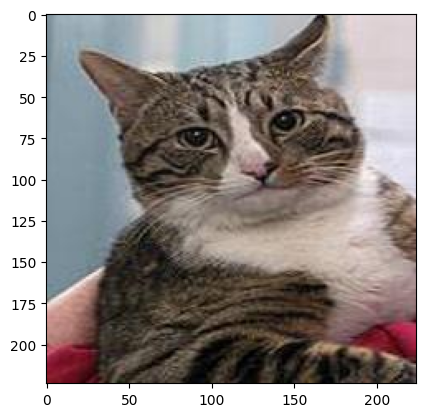

In [64]:
#resized cat image
img = mpimg.imread('/content/images_resized/cat.10772.jpg')
plt.imshow(img)
plt.show()

**Creating labels for resized images**

Cat --> 0

Dog --> 1

In [65]:
#creating for loop to assign labels
filenames = os.listdir('/content/images_resized/')

labels = []

for i in range(2000):
  file_names = filenames[i]
  label = file_names[0:3]

  if label == 'dog':
    labels.append(1)
  else:
    labels.append(0)




In [66]:
print(filenames[0:15])
print(len(filenames))

['dog.4708.jpg', 'dog.11061.jpg', 'dog.10984.jpg', 'dog.2742.jpg', 'dog.9525.jpg', 'cat.10772.jpg', 'dog.4460.jpg', 'cat.5592.jpg', 'cat.8858.jpg', 'dog.5734.jpg', 'cat.7714.jpg', 'cat.3887.jpg', 'dog.5666.jpg', 'dog.4419.jpg', 'dog.4255.jpg']
2000


In [67]:
print(labels[0:15])

[1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1]


In [68]:
#counting the image of dogs and cats out of 2000 images

values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 983 1017]


Converting all resized images to numpy array

In [90]:
import cv2
import glob

In [70]:
image_directory = '/content/images_resized/'
image_extention = ['png','jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extention]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [71]:
print(dog_cat_images)

[[[[114 123 110]
   [114 123 110]
   [114 123 110]
   ...
   [ 99 108  95]
   [100 109  96]
   [101 110  97]]

  [[111 120 107]
   [111 120 107]
   [112 121 108]
   ...
   [100 109  96]
   [101 110  97]
   [101 110  97]]

  [[108 118 102]
   [108 118 102]
   [109 119 103]
   ...
   [101 111  95]
   [102 112  96]
   [102 112  96]]

  ...

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [ 86  88  88]
   [ 77  79  79]
   [ 79  81  81]]

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [ 98 100 100]
   [ 89  91  91]
   [ 86  88  88]]

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [109 111 111]
   [106 108 108]
   [ 97  99  99]]]


 [[[160 158 157]
   [159 157 156]
   [160 158 157]
   ...
   [156 156 156]
   [158 158 158]
   [159 159 159]]

  [[166 164 163]
   [165 163 162]
   [164 162 161]
   ...
   [158 158 158]
   [159 159 159]
   [160 160 160]]

  [[171 169 168]
   [169 167 166]
   [167 165 164]
   ...
   [160 160 160]
   [161 161 161]
   [162 162

In [72]:
print(type(dog_cat_images))

<class 'numpy.ndarray'>


In [73]:
dog_cat_images.shape

(2000, 224, 224, 3)

In [78]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [77]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [76]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 training images

400 test images

In [75]:
# Scalling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255



In [74]:
print(X_train_scaled)

[[[[0.7254902  0.67843137 0.67058824]
   [0.7254902  0.67843137 0.67058824]
   [0.7254902  0.67843137 0.67058824]
   ...
   [0.30588235 0.29803922 0.29411765]
   [0.28627451 0.29019608 0.28235294]
   [0.39215686 0.39607843 0.38823529]]

  [[0.67843137 0.63137255 0.62352941]
   [0.67843137 0.63137255 0.62352941]
   [0.67843137 0.63137255 0.62352941]
   ...
   [0.2        0.19215686 0.18823529]
   [0.18039216 0.18431373 0.17647059]
   [0.28235294 0.28627451 0.27843137]]

  [[0.67058824 0.62352941 0.61568627]
   [0.67058824 0.62352941 0.61568627]
   [0.67058824 0.62352941 0.61568627]
   ...
   [0.21960784 0.21176471 0.20784314]
   [0.19215686 0.19607843 0.18823529]
   [0.28627451 0.29019608 0.28235294]]

  ...

  [[0.31372549 0.34901961 0.40392157]
   [0.3254902  0.36078431 0.41568627]
   [0.3254902  0.36078431 0.41568627]
   ...
   [0.18823529 0.24705882 0.28235294]
   [0.2        0.26666667 0.30196078]
   [0.29411765 0.36078431 0.39607843]]

  [[0.30196078 0.33333333 0.38431373]
   [0.3

**Building the Neural Network**

In [94]:
pip install tf_keras

In [95]:

import tensorflow as tf
import tensorflow_hub as hub
import tf_keras

In [88]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape = (224,224,3), trainable=False )


In [98]:
num_of_classes = 2 #dog and cut

model = tf_keras.Sequential([
    pretrained_model,
    tf_keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense_1 (Dense)             (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [100]:
model.compile(
    optimizer = 'adam',
    loss = tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics='acc'
)

In [103]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 43s 866ms/step - loss: 0.0671 - acc: 0.9800
Epoch 2/5
50/50 [==============================] - 34s 684ms/step - loss: 0.0512 - acc: 0.9862
Epoch 3/5
50/50 [==============================] - 36s 708ms/step - loss: 0.0430 - acc: 0.9875
Epoch 4/5
50/50 [==============================] - 44s 875ms/step - loss: 0.0320 - acc: 0.9944
Epoch 5/5
50/50 [==============================] - 38s 761ms/step - loss: 0.0299 - acc: 0.9919


In [104]:
score_loss, acc = model.evaluate(X_test_scaled, Y_test)
print('loss', score_loss)
print('Accuracy ', acc)

13/13 [==============================] - 12s 847ms/step - loss: 0.0411 - acc: 0.9800
loss 0.04106921702623367
Accuracy  0.9800000190734863


**Create Predictive system**

Path of the image to be predicted/content/cat_true_image.jpg


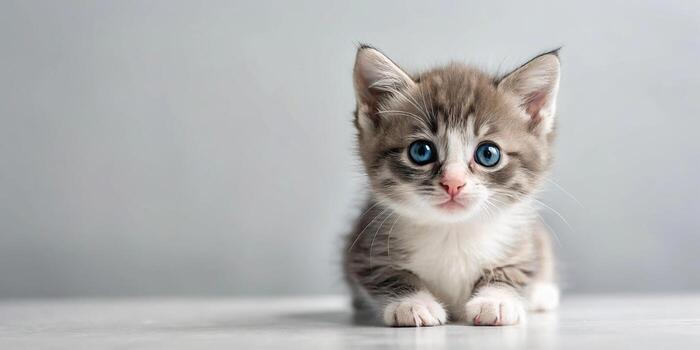

1/1 [==============================] - 0s 42ms/step
This is a Cat


In [107]:
input_image_path = input('Path of the image to be predicted')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resized/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
  print('This is a Cat')
else:
  print('This is a Dog')



Path of the image to be predicted /content/dog_play_concerns.jpg


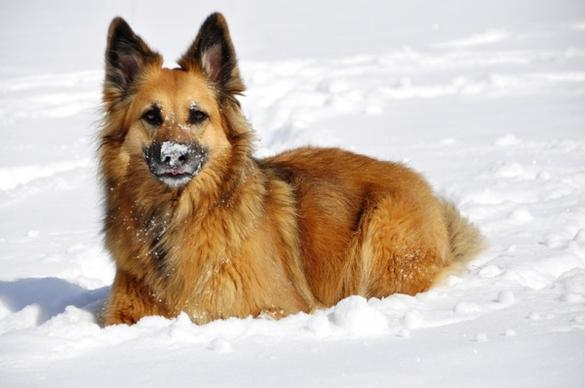

1/1 [==============================] - 0s 43ms/step
This is a Dog


In [109]:
input_image_path = input('Path of the image to be predicted ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resized/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
  print('This is a Cat')
else:
  print('This is a Dog')